# gyokuken — Visualization Examples

This notebook walks through the four plotting functions in `megumi.gyokuken` using three scikit-learn toy datasets, one for each target type the module understands:

| Example | Dataset | Target type |
|---------|---------|-------------|
| 1 | Breast Cancer | Binary classification |
| 2 | Diabetes | Regression |
| 3 | Wine | Multiclass classification |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_diabetes, load_wine

from megumi.gyokuken import (
    plot_bivariate,
    plot_distribution,
    plot_correlation,
    plot_missing,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

## Example 1 — Binary Classification: Breast Cancer

**Target:** `0` = malignant, `1` = benign  
**Features:** 30 numeric measurements derived from digitized images of fine needle aspirates.

In [2]:
data = load_breast_cancer()
df_bc = pd.DataFrame(data.data, columns=data.feature_names)
df_bc["target"] = data.target  # 0 = malignant, 1 = benign

print(f"Shape: {df_bc.shape}")
print(f"Target distribution:\n{df_bc['target'].value_counts().to_string()}")
df_bc.head()

Shape: (569, 31)
Target distribution:
target
1    357
0    212


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Missing Values

Inject synthetic missing values to demonstrate `plot_missing` and the `"Missing"` bucket in bivariate plots.

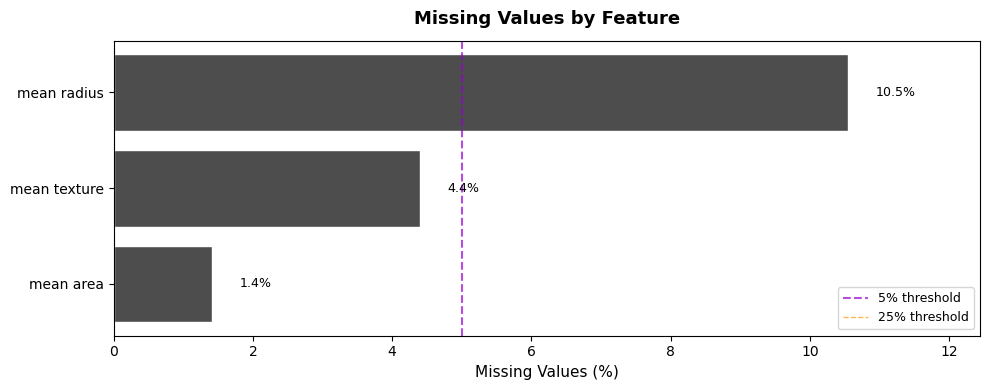

In [3]:
rng = np.random.default_rng(42)
df_bc_missing = df_bc.copy()
idx = rng.choice(df_bc_missing.index, size=60, replace=False)
df_bc_missing.loc[idx[:60], "mean radius"] = np.nan
df_bc_missing.loc[idx[:25], "mean texture"] = np.nan
df_bc_missing.loc[idx[:8],  "mean area"] = np.nan

plot_missing(df_bc_missing)

In [4]:
df_bc_missing[["mean radius", "mean texture", "mean area"]].isna().mean()

mean radius     0.105448
mean texture    0.043937
mean area       0.014060
dtype: float64

### Bivariate Plot — Continuous Feature

`mean radius` is a continuous feature so it is automatically quantile-binned.  
The right axis shows the mean target (benign rate) per bin; the dashed line is the population average.

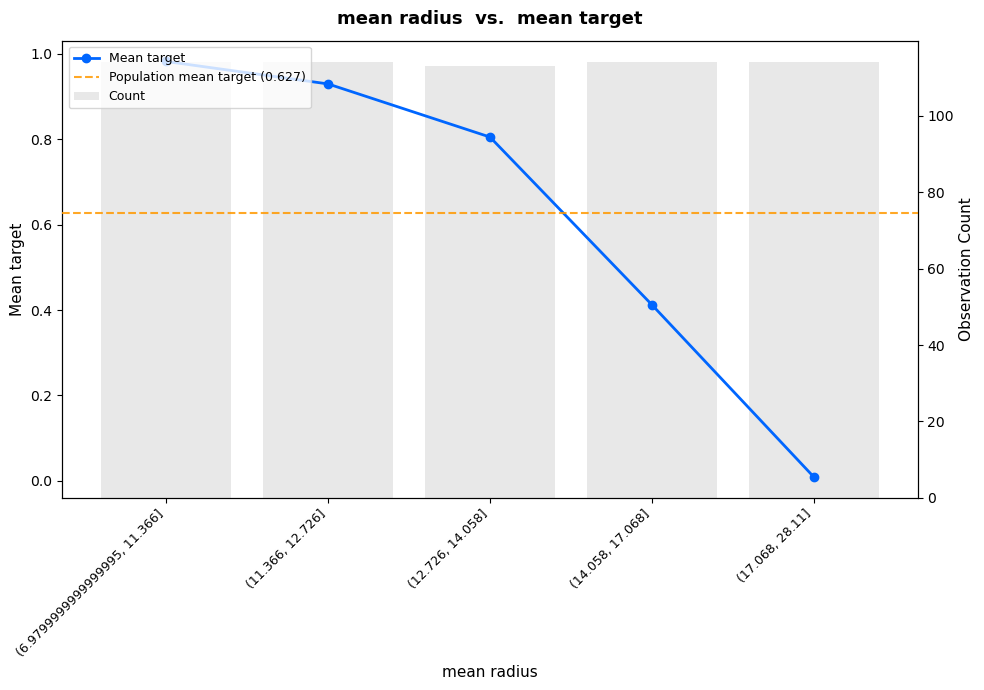

In [5]:
# No missing values — clean bivariate
plot_bivariate(df_bc, feature="mean radius", target="target")

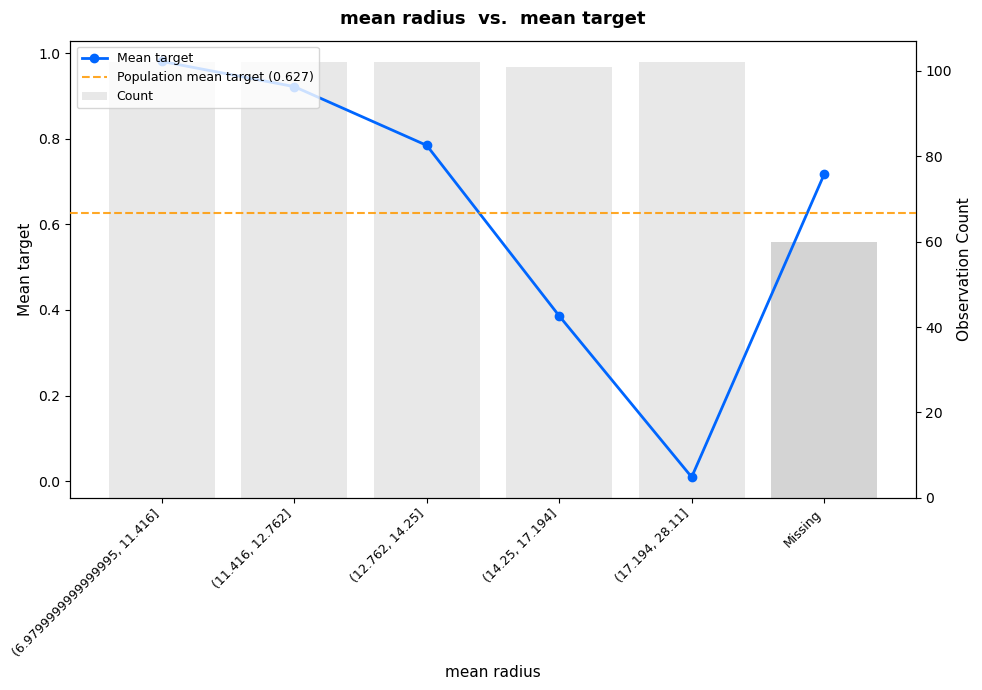

In [6]:
# Same feature with synthetic missing values — the grey "Missing" bucket appears at the end.
# Notice the benign rate for missing observations vs. the other bins.
plot_bivariate(df_bc_missing, feature="mean radius", target="target")

### Distribution Plots

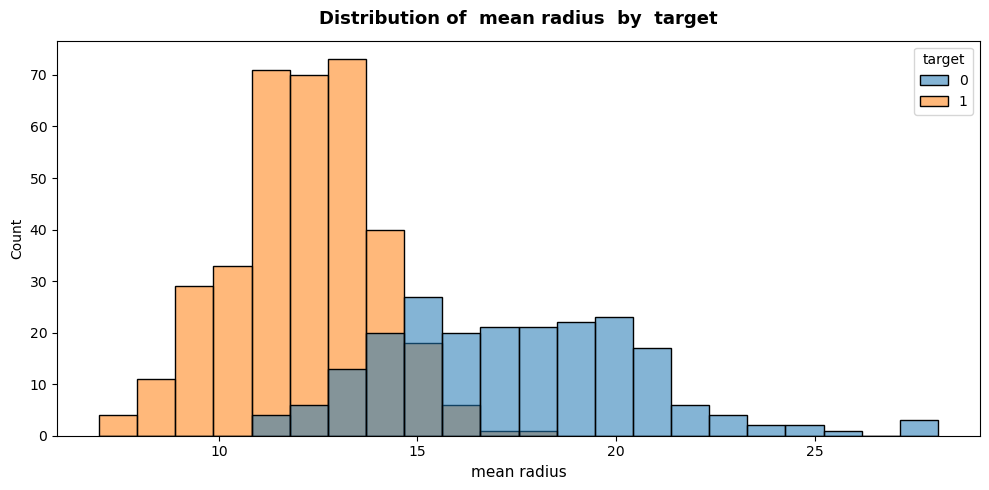

In [7]:
plot_distribution(df_bc, feature="mean radius", target="target", kind="histogram")

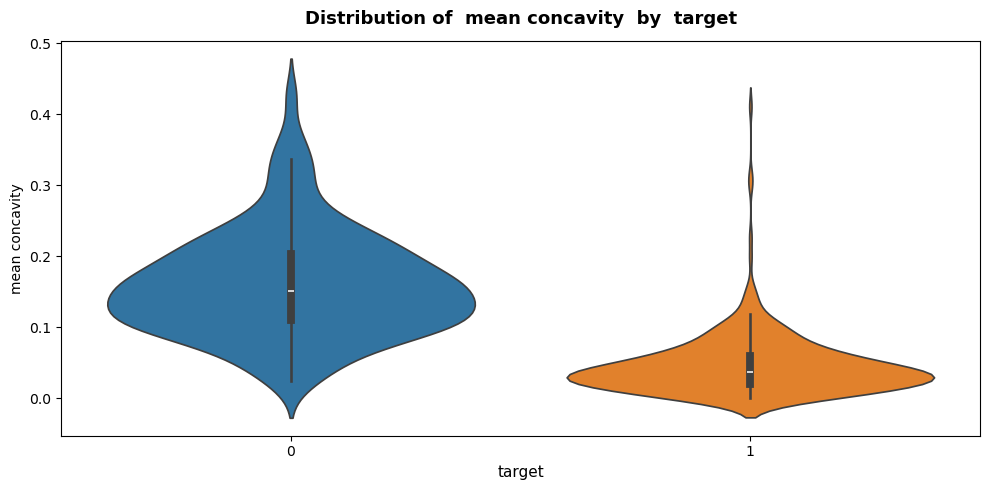

In [8]:
plot_distribution(df_bc, feature="mean concavity", target="target", kind="violin")

### Correlation Heatmap

Using a subset of 8 features to keep the heatmap readable.

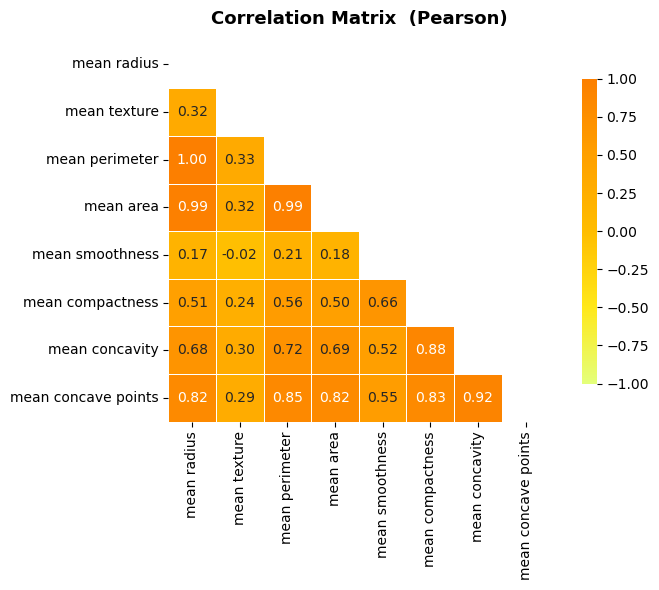

In [9]:
features_bc = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean smoothness", "mean compactness",
    "mean concavity", "mean concave points",
]
plot_correlation(df_bc, features=features_bc, palette="Wistia")

---

## Example 2 — Regression: Diabetes

**Target:** `progression` — a quantitative measure of disease progression one year after baseline (continuous).  
**Features:** 10 baseline variables (age, sex, bmi, blood pressure, and 6 serum measurements).

In [10]:
data = load_diabetes()
df_diab = pd.DataFrame(data.data, columns=data.feature_names)
df_diab["progression"] = data.target

print(f"Shape: {df_diab.shape}")
print(f"Target range: {df_diab['progression'].min():.1f} – {df_diab['progression'].max():.1f}")
df_diab.head()

Shape: (442, 11)
Target range: 25.0 – 346.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Bivariate Plot — Continuous Feature vs Continuous Target

For a regression target the right axis shows the mean target value per bin rather than an event rate.

/var/folders/gc/x3q0m4h564d61kh41xdz_gy00000gn/T/ipykernel_61320/1691203092.py:1: UserWarning: Target 'progression' appears to be continuous (regression).
The right axis shows mean target magnitude per bin, not an event rate.
Bins with similar counts but different mean values indicate a predictive relationship.
  plot_bivariate(df_diab, feature="bmi", target="progression")


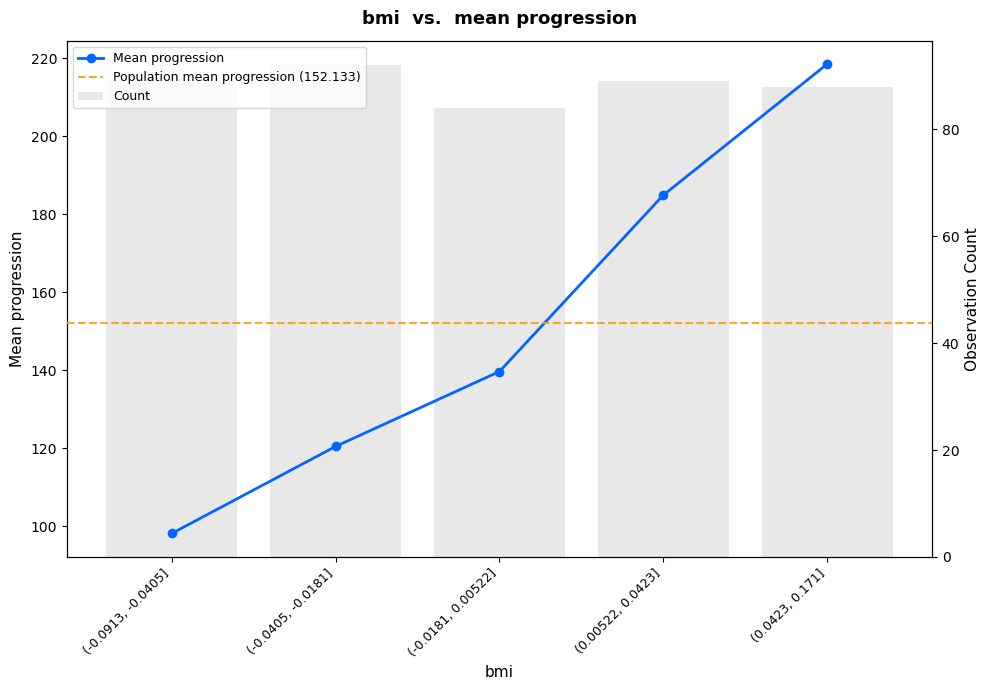

In [11]:
plot_bivariate(df_diab, feature="bmi", target="progression")

### Distribution Plots

For a continuous target `plot_distribution` automatically bins the target into quantile groups for colouring.

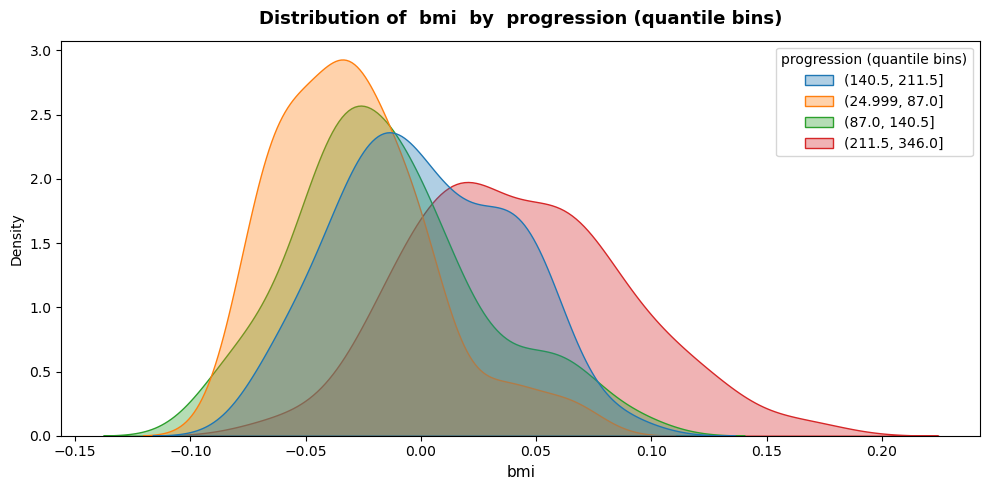

In [12]:
plot_distribution(df_diab, feature="bmi", target="progression", kind="kde")

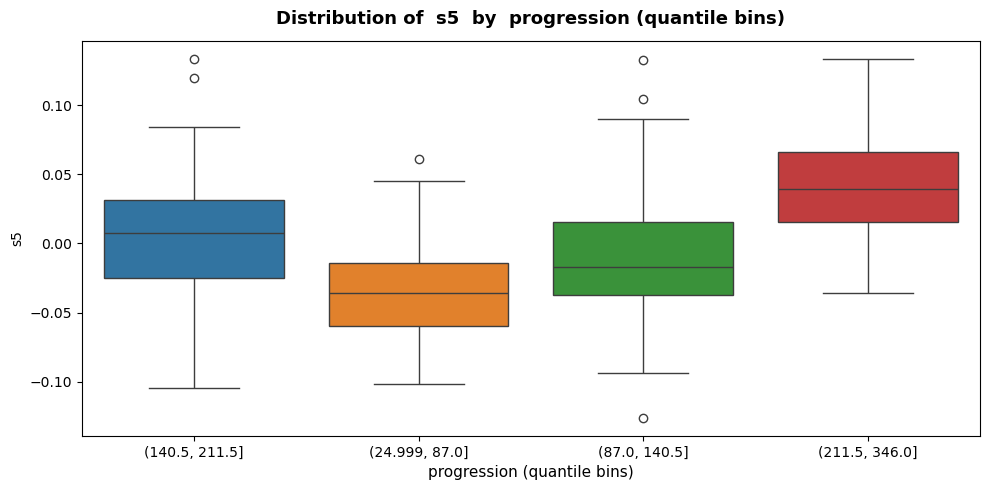

In [13]:
plot_distribution(df_diab, feature="s5", target="progression", kind="boxplot")

### Correlation Heatmap — Spearman

Spearman is often more informative for medical/clinical data where relationships are monotonic but not necessarily linear.

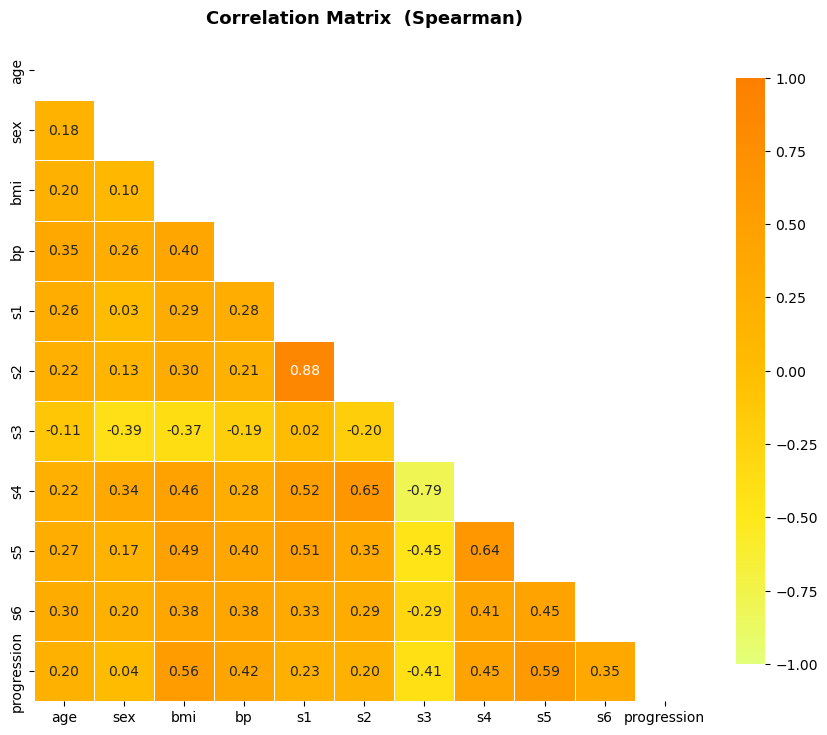

In [14]:
plot_correlation(df_diab, method="spearman")

---

## Example 3 — Multiclass Classification: Wine

**Target:** three cultivars of wine (classes 0, 1, 2).  
**Features:** 13 chemical measurements (alcohol, malic acid, ash, etc.).

In [15]:
data = load_wine()
df_wine = pd.DataFrame(data.data, columns=data.feature_names)
df_wine["cultivar"] = data.target  # 0, 1, 2 — used for bivariate (numeric mean makes sense as class code)
df_wine["cultivar_name"] = df_wine["cultivar"].map(
    {0: "Cultivar 0", 1: "Cultivar 1", 2: "Cultivar 2"}
)  # string labels — used for distribution plots

print(f"Shape: {df_wine.shape}")
print(f"Target distribution:\n{df_wine['cultivar_name'].value_counts().to_string()}")
df_wine.head()

Shape: (178, 15)
Target distribution:
cultivar_name
Cultivar 1    71
Cultivar 0    59
Cultivar 2    48


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar,cultivar_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Cultivar 0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Cultivar 0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Cultivar 0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Cultivar 0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Cultivar 0


### Bivariate Plot

The right axis shows the mean class code per bin — bins where one cultivar dominates will pull the mean towards 0 or 2.

In [16]:
plot_bivariate(df_wine, feature="alcohol", target="cultivar")

ValueError: plot_bivariate does not support multiclass targets.
'cultivar' has 3 unique classes.
Computing a per-bucket mean is only meaningful for binary or continuous targets.
Use plot_distribution to compare feature distributions across multiple classes.

### Distribution Plots

Using the string cultivar names for clearer legend labels in distribution plots.

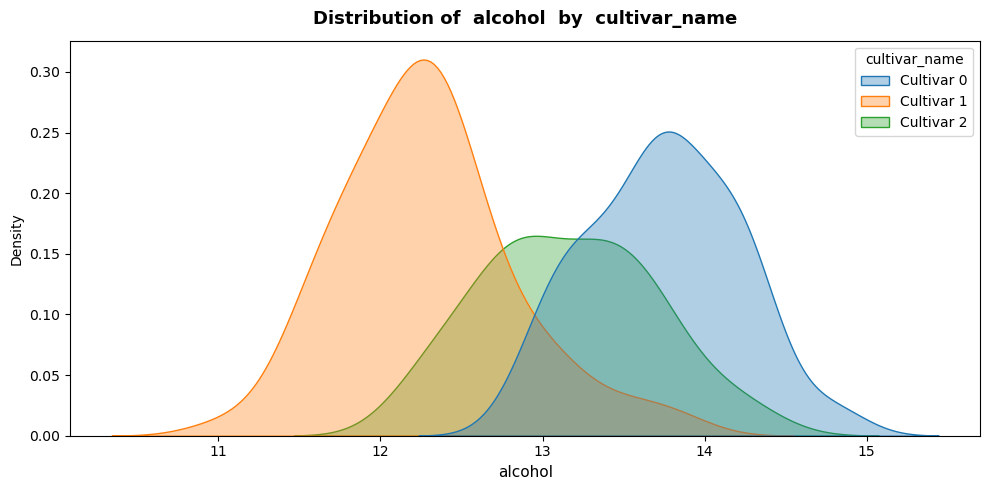

In [17]:
plot_distribution(
    df_wine, feature="alcohol", target="cultivar_name", kind="kde"
)

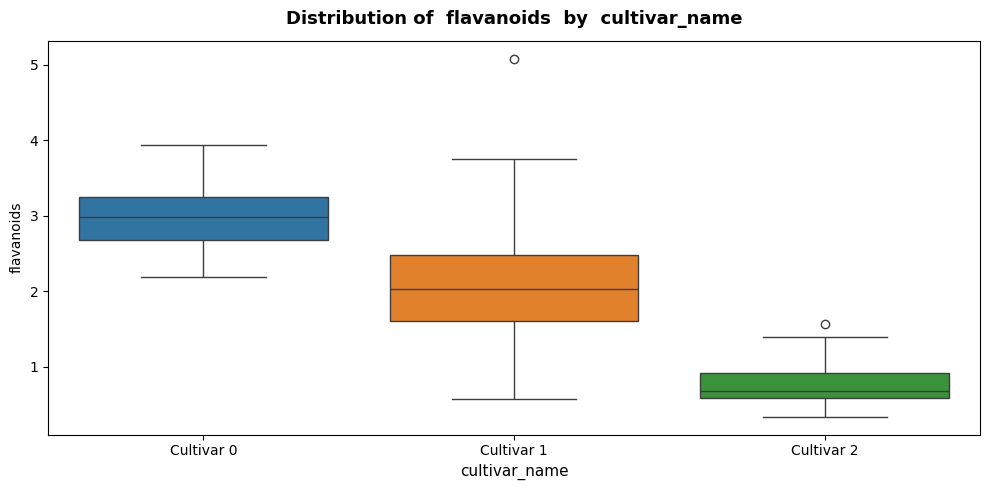

In [18]:
plot_distribution(
    df_wine, feature="flavanoids", target="cultivar_name", kind="boxplot"
)

### Correlation Heatmap

In [19]:
plot_correlation(df_wine, target = "cultivar_name")

ValueError: plot_correlation does not support multiclass targets.
'cultivar_name' has 3 unique classes.
Pairwise correlation is not meaningful for unordered multi-class targets.
Use plot_distribution to compare feature distributions across classes.